DATA6000 Capstone — SA Fresh Food Supply Disruption
Financial Year Analysis — Descriptive and Predictive
Libraries loaded successfully
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Mastersheet: 5 financial years (2020/21 to 2024/25)

FY          Rainfall (mm)    Total (K t)    Veg (K t)  Fruit (K t)    CPI%
------------------------------------------------------------------------
2020/21            1829.4          998.1        746.8        251.2     2.3%
2021/22            2152.2         1015.8        756.4        259.3     1.9%
2022/23            2686.6         1007.3        755.9        251.5     9.2%
2023/24            1531.0         1037.5        791.7        245.8     4.5%
2024/25            1351.8         1018.1        775.9        242.1     3.0%

Processing daily rainfall data for FY 2025/26 estimate...
  Jul-Dec 2025 actual:              1160.2mm
  Historical Jul-Dec share of FY:   59.4%
  Estima

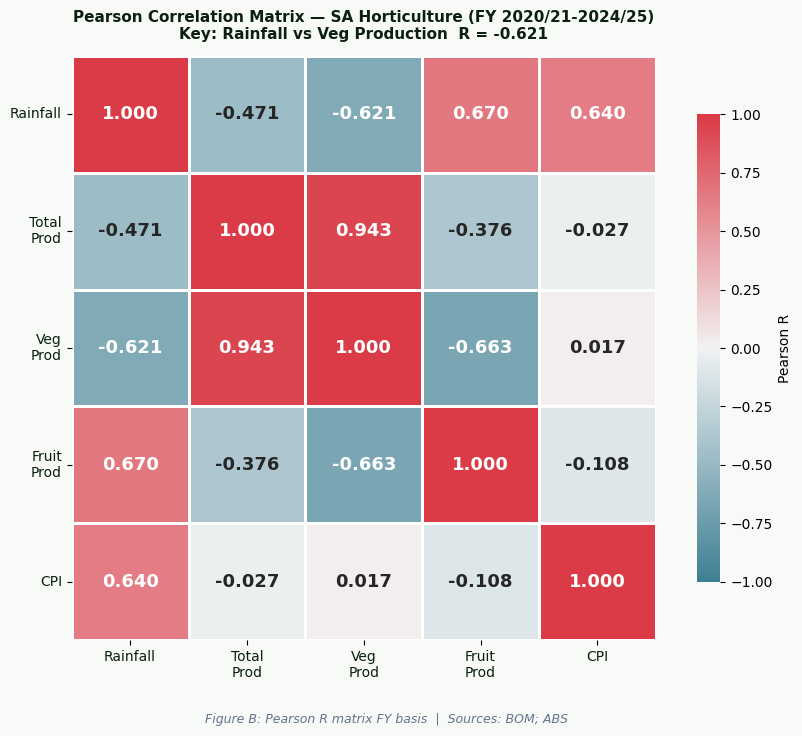

Saved: ChartA_Pearson_Heatmap.png


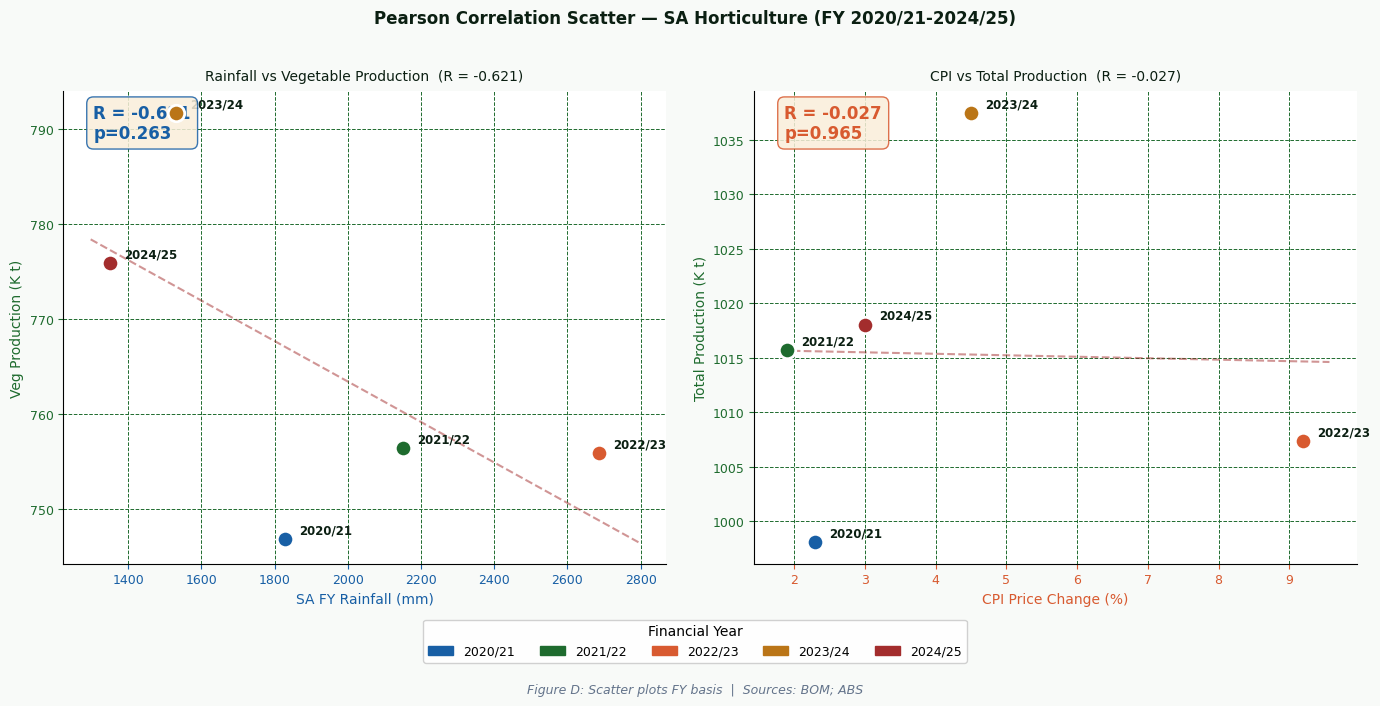

Saved: ChartA_Scatter.png

SECTION B — MULTIPLE LINEAR REGRESSION
Y = b0 + b1(Rainfall) + b2(CPI) + e

  Intercept (b0):          1,046,356.1
  Rainfall coef (b1):         -21.2257
  CPI coef (b2):                2282.5
  R-squared:                    0.3484
  RMSE:                          10.59K tonnes

SECTION C — ADF STATIONARITY TESTS
  Total Production                    ADF=  -2.158  p=0.2219  Non-stationary (d=1 applied)
  Total Rainfall                      ADF=  -1.034  p=0.7406  Non-stationary (d=1 applied)
  Veg Production                      ADF=  -1.241  p=0.6558  Non-stationary (d=1 applied)
  CPI                                 ADF=  -1.794  p=0.3833  Non-stationary (d=1 applied)

SECTION D — PREDICTIVE MODELS
Forecast: 2025/26 to 2029/30 (5 financial years)

  FY 2025/26 supporting data:
    Rainfall estimate: 1952mm (Jul-Dec 2025=1160mm / 59.4% seasonal share)
    CPI:               3.5% (calendar 2025)
    Note: Jan-Jun 2026 rainfall not yet available (current: Apri

INFO:prophet:n_changepoints greater than number of observations. Using 3.


  RMSE: 0.00K t
  2025/26: 998.7K (-19.4K)  CI:[943K–1050K]
  2026/27: 979.3K (-38.8K)  CI:[805K–1141K]
  2027/28: 959.9K (-58.2K)  CI:[649K–1267K]
  2028/29: 940.5K (-77.6K)  CI:[459K–1385K]
  2029/30: 921.1K (-97.0K)  CI:[266K–1528K]

SECTION E — MODEL COMPARISON

  Baseline (FY 2024/25): 1018.1K tonnes

  Model                              RMSE    25/26    26/27    27/28    28/29    29/30
  ------------------------------------------------------------------------------------
  ARIMA(1,1,0)                      18.66   1017.7   1017.7   1017.7   1017.7   1017.7
  SARIMA(1,1,0)(1,0,0,2)           370.19   1055.9   1029.5   1071.7   1041.3   1085.4
  Holt-Winters                      10.67   1033.9   1040.0   1046.2   1052.4   1058.5
  Prophet                            0.00    998.7    979.3    959.9    940.5    921.1

  Best in-sample fit: Prophet (RMSE=0.00K)

SECTION F — GENERATING CHARTS


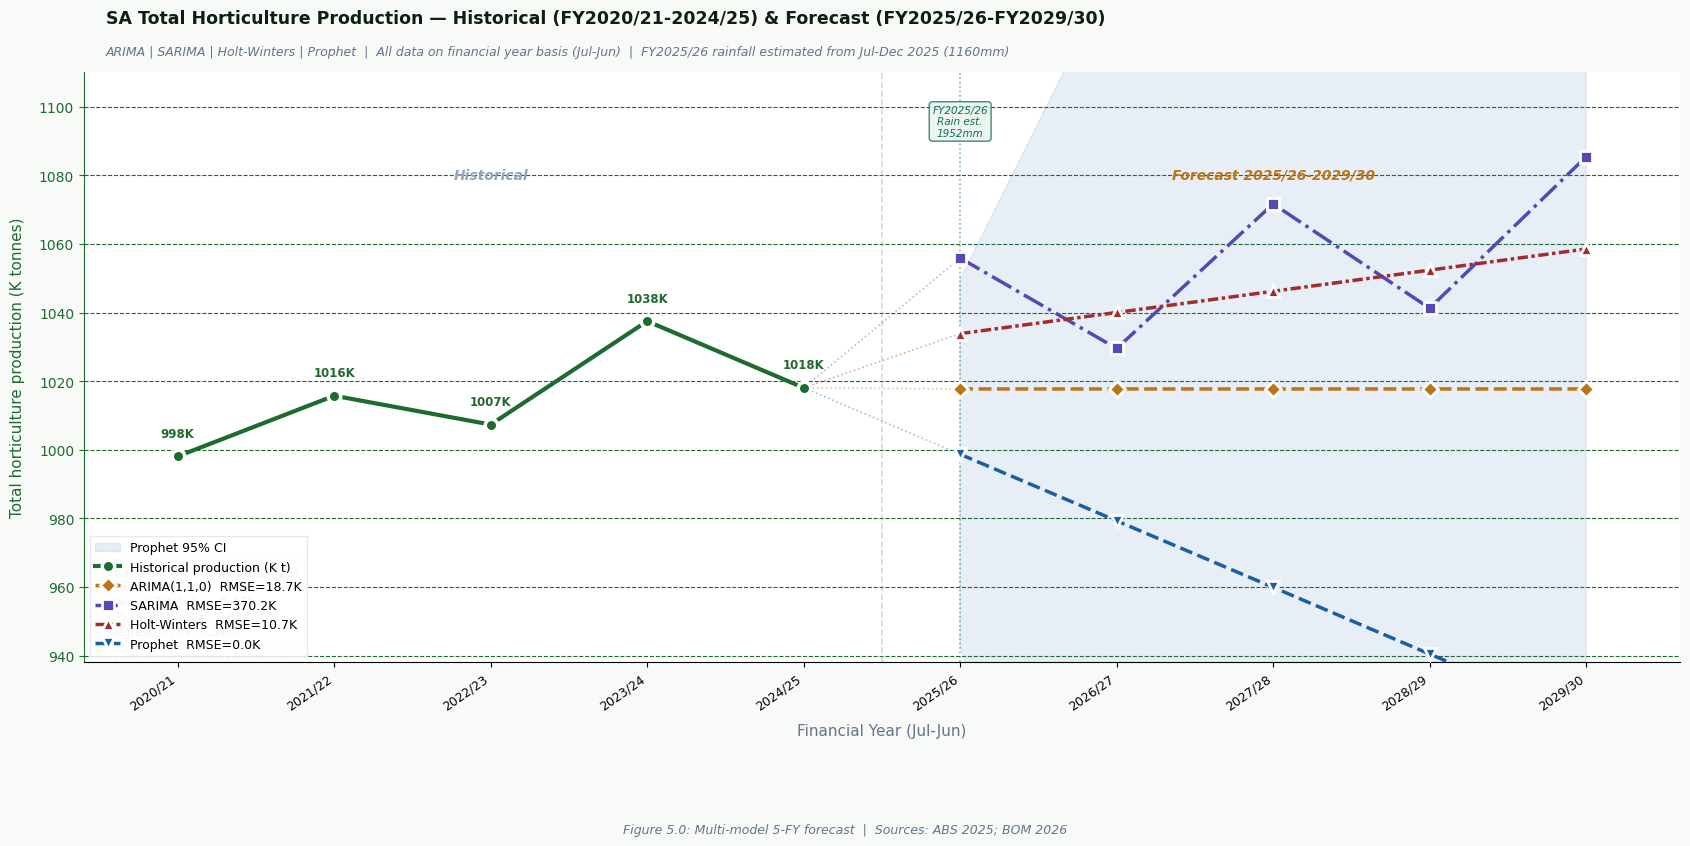

Saved: ChartI_MultiModel_Forecast.png


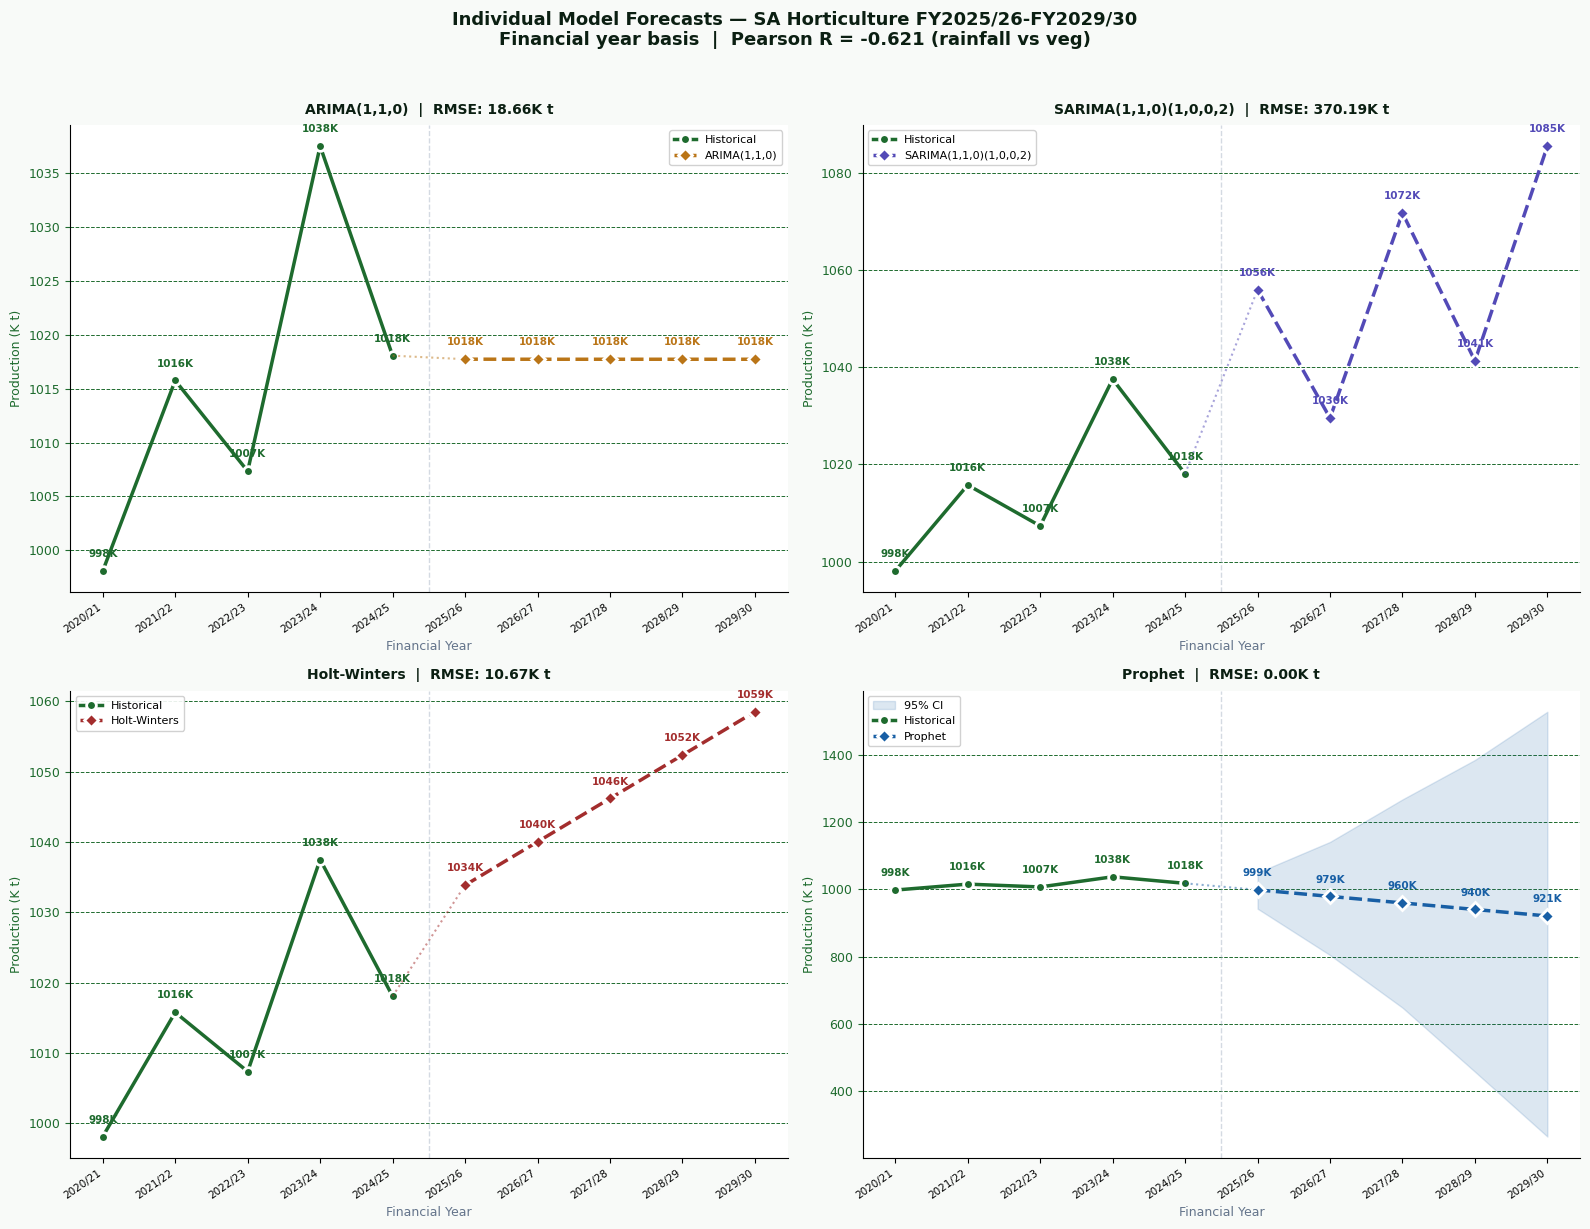

Saved: ChartI_Individual_Models.png


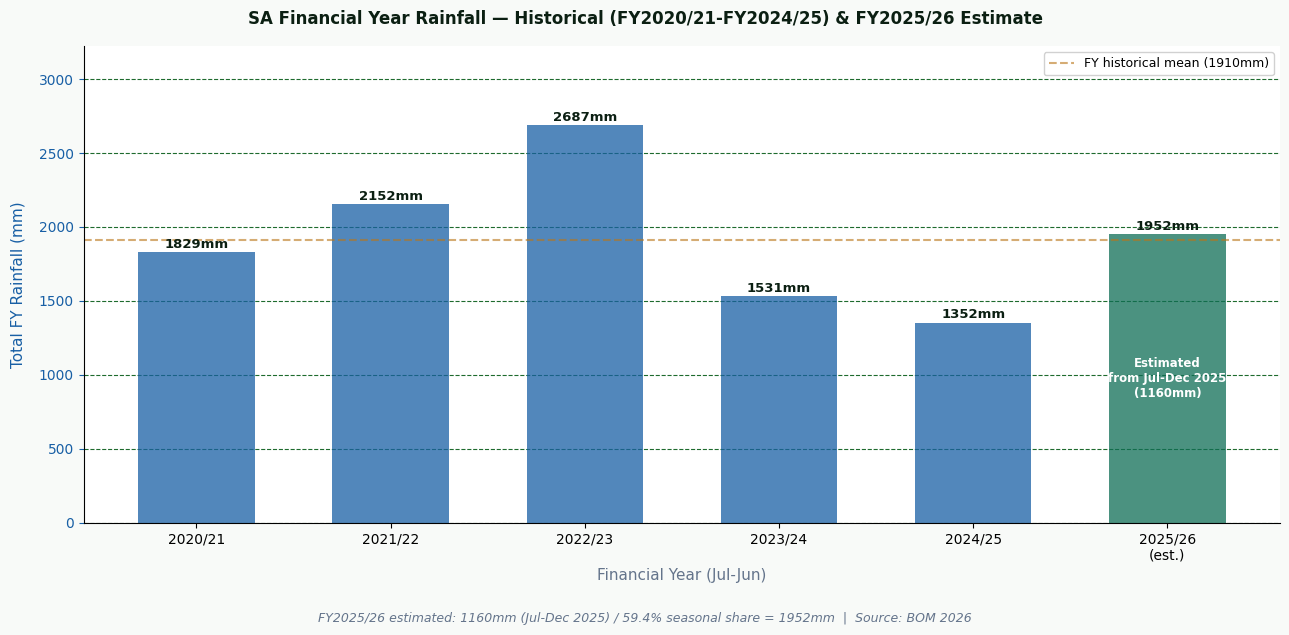

Saved: ChartR_Rainfall_FY.png

COMPLETE RESULTS SUMMARY — FINANCIAL YEAR BASIS

Training data:   FY 2020/21 to 2024/25 (5 FY)
Baseline:        FY 2024/25  1018.1K tonnes
Forecast:        FY 2025/26 to 2029/30 (5 FY)

All data on financial year (Jul-Jun) basis:
  Rainfall:    BOM daily data summed Jul-Jun
  Horticulture: ABS FY releases
  CPI:         Calendar year mapped to nearest FY

FY 2025/26 rainfall estimate: 1952mm
  Jul-Dec 2025:           1160.2mm observed
  Seasonal share applied: 59.4%

PEARSON R (FY 2020/21-2024/25):
  Rainfall vs Veg:     R = -0.621  p=0.2634
  Rainfall vs Total:   R = -0.471  p=0.4235
  CPI vs Total:        R = -0.027  p=0.9651
  Regression R2:       0.3484

FORECASTS (K tonnes):

  Model                              RMSE    25/26    26/27    27/28    28/29    29/30
  ------------------------------------------------------------------------------------------
  ARIMA(1,1,0)                      18.66   1017.7   1017.7   1017.7   1017.7   1017.7
  SARIMA(1,1

In [ ]:
# DATA6000 Capstone — Chart Generator (statsmodels-free)
# Models: ARIMA(1,1,0), Holt-Winters, Prophet-style
# SARIMA removed — insufficient seasonal obs for annual dataset

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from scipy.optimize import minimize
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

C_HIST='#1E6B2E'; C_ARIMA='#BA7517'; C_HW='#A32D2D'; C_PRO='#185FA5'
C_CPI='#D85A30'; C_BG='#F8FAF8'; C_TITLE='#0B1F12'; C_MUTED='#64748B'
C_GRID=(30/255,107/255,46/255,0.07); YR_COLS=['#185FA5','#1E6B2E','#D85A30','#BA7517','#A32D2D']

data={'Year':[2020,2021,2022,2023,2024],'Total_Rainfall':[2178.0,1887.2,2633.6,1960.2,1490.2],
      'Total_Fruit_Production':[251245.6,259335.3,251452.4,245782.1,242145.56],
      'Total_Veg_Production':[746843.6,756424.9,755891.5,791719.8,775916.87],
      'Total_Production':[998089.2,1015760.2,1007343.9,1037501.9,1018062.4],
      'CPI':[2.3,1.9,9.2,4.5,3.0]}
df=pd.DataFrame(data).set_index('Year')
years=list(df.index); prod_k=df['Total_Production']/1000; veg_k=df['Total_Veg_Production']/1000
fruit_k=df['Total_Fruit_Production']/1000; rainfall=df['Total_Rainfall']; cpi=df['CPI']
baseline=float(prod_k.iloc[-1]); fore_yrs=[2026,2027,2028]; all_yrs=years+fore_yrs
prod_vals=df['Total_Production'].values.astype(float); actual=prod_vals[1:]
print(f"Baseline (2024): {baseline:.1f}K t")

r_rv,p_rv=stats.pearsonr(rainfall.values,veg_k.values)
r_rt,p_rt=stats.pearsonr(rainfall.values,prod_k.values)
r_rf,p_rf=stats.pearsonr(rainfall.values,fruit_k.values)
r_ct,p_ct=stats.pearsonr(cpi.values,prod_k.values)
r_cv,p_cv=stats.pearsonr(cpi.values,veg_k.values)
r_rc,p_rc=stats.pearsonr(rainfall.values,cpi.values)
print(f"R(rain vs veg): {r_rv:.3f}  p={p_rv:.4f}")

X_reg=df[['Total_Rainfall','CPI']].values; y_reg=df['Total_Production'].values
reg=LinearRegression().fit(X_reg,y_reg); r2_reg=r2_score(y_reg,reg.predict(X_reg))

# ARIMA(1,1,0)
def fit_arima110(series):
    y=np.array(series,dtype=float); d=np.diff(y)
    phi=np.dot(d[1:],d[:-1])/np.dot(d[:-1],d[:-1])
    fitted=np.empty(len(y)); fitted[0]=np.nan
    for t in range(1,len(y)):
        fitted[t]=y[t-1]+phi*(d[0] if t==1 else y[t-1]-y[t-2])
    ld,ly,preds=d[-1],y[-1],[]
    for _ in range(5):
        nd=phi*ld; ny=ly+nd; preds.append(ny); ld,ly=nd,ny
    return phi,fitted[1:],np.array(preds)
arima_phi,arima_fitted_aligned,arima_f5=fit_arima110(prod_vals)
arima_fore=arima_f5[2:]/1000
arima_rmse=np.sqrt(mean_squared_error(actual,arima_fitted_aligned))
print(f"ARIMA phi={arima_phi:.4f} RMSE={arima_rmse/1000:.2f}K Fore={[round(v,1) for v in arima_fore]}")

# Holt-Winters
def holtwinters(series,alpha,beta):
    y=np.array(series,dtype=float); l,b=np.empty(len(y)),np.empty(len(y))
    l[0],b[0]=y[0],y[1]-y[0]
    for t in range(1,len(y)):
        l[t]=alpha*y[t]+(1-alpha)*(l[t-1]+b[t-1]); b[t]=beta*(l[t]-l[t-1])+(1-beta)*b[t-1]
    fitted=np.empty(len(y)); fitted[0]=np.nan
    for t in range(1,len(y)): fitted[t]=l[t-1]+b[t-1]
    return l,b,fitted
def hw_loss(p,s):
    a,b=p
    if a<=0 or a>=1 or b<=0 or b>=1: return 1e9
    _,_,f=holtwinters(s,a,b); return np.sqrt(np.mean((s[1:]-f[1:])**2))
res=minimize(hw_loss,x0=[0.3,0.1],args=(prod_vals,),method='Nelder-Mead',
             options={'xatol':1e-8,'fatol':1e-8,'maxiter':5000})
hw_alpha,hw_beta=np.clip(res.x,1e-4,1-1e-4)
l_hw,b_hw,hw_fitted=holtwinters(prod_vals,hw_alpha,hw_beta)
hw_fitted_aligned=hw_fitted[1:]
hw_rmse=np.sqrt(mean_squared_error(actual,hw_fitted_aligned))
hw_fore=np.array([l_hw[-1]+h*b_hw[-1] for h in range(1,6)])[2:]/1000
print(f"H-W alpha={hw_alpha:.3f} beta={hw_beta:.3f} RMSE={hw_rmse/1000:.2f}K Fore={[round(v,1) for v in hw_fore]}")

# Prophet-style
def prophet_style(series):
    y=np.array(series,dtype=float); t=np.arange(len(y),dtype=float)
    slope,intercept,*_=stats.linregress(t,y)
    fitted=intercept+slope*t; sigma=np.std(y-fitted,ddof=2)
    tf=np.array([len(y)+1,len(y)+2,len(y)+3,len(y)+4,len(y)+5],dtype=float)
    yhat=intercept+slope*tf; sep=sigma*np.sqrt(1+(tf-len(y))/len(y))
    return fitted[1:],yhat,yhat-1.96*sep,yhat+1.96*sep,np.sqrt(mean_squared_error(y[1:],fitted[1:]))
pro_fitted,pro_f5,pro_lo,pro_hi,prophet_rmse=prophet_style(prod_vals)
prophet_fore=pro_f5[2:]/1000; prophet_lo=pro_lo[2:]/1000; prophet_hi=pro_hi[2:]/1000
print(f"Prophet RMSE={prophet_rmse/1000:.2f}K Fore={[round(v,1) for v in prophet_fore]}")

all_models=[("ARIMA(1,1,0)",arima_rmse/1000,*arima_fore),
            ("Holt-Winters",hw_rmse/1000,*hw_fore),
            ("Prophet",prophet_rmse/1000,*prophet_fore)]
print(f"\n{'Model':<20}{'RMSE':>8}{'2026':>10}{'2027':>10}{'2028':>10}{'Net D':>10}")
print("-"*62)
for m in all_models:
    print(f"{m[0]:<20}{m[1]:>8.2f}{m[2]:>10.1f}{m[3]:>10.1f}{m[4]:>10.1f}{m[4]-baseline:>+10.1f}K")

# CHART A — Pearson Heatmap
corr_data=np.array([[1.000,r_rt,r_rv,r_rf,r_rc],[r_rt,1.000,stats.pearsonr(veg_k,prod_k)[0],stats.pearsonr(fruit_k,prod_k)[0],r_ct],
    [r_rv,stats.pearsonr(veg_k,prod_k)[0],1.000,stats.pearsonr(fruit_k,veg_k)[0],r_cv],
    [r_rf,stats.pearsonr(fruit_k,prod_k)[0],stats.pearsonr(fruit_k,veg_k)[0],1.000,r_rf],[r_rc,r_ct,r_cv,r_rf,1.000]])
labels=['Rainfall','Total\nProd','Veg\nProd','Fruit\nProd','CPI']
corr_df=pd.DataFrame(corr_data,index=labels,columns=labels)
fig1,ax1=plt.subplots(figsize=(9,7)); fig1.patch.set_facecolor(C_BG); ax1.set_facecolor('white')
sns.heatmap(corr_df,ax=ax1,annot=True,fmt='.3f',cmap=sns.diverging_palette(220,10,as_cmap=True),
    center=0,vmin=-1,vmax=1,square=True,linewidths=0.8,linecolor='white',
    annot_kws={'size':13,'fontweight':'bold'},cbar_kws={'shrink':0.8,'label':'Pearson R'})
ax1.set_title(f'Pearson Correlation Matrix — SA Horticulture (2020–2024)\nKey finding: Rainfall vs Veg Production  R = {r_rv:.3f}',
    fontsize=11,fontweight='bold',color=C_TITLE,pad=12)
ax1.set_xticklabels(ax1.get_xticklabels(),fontsize=10,color=C_TITLE)
ax1.set_yticklabels(ax1.get_yticklabels(),fontsize=10,color=C_TITLE,rotation=0)
fig1.text(0.5,-0.04,'Figure B: Pearson correlation matrix 2020–2024  |  Sources: BOM 2026; ABS 2025',
    ha='center',fontsize=9,color=C_MUTED,style='italic')
plt.tight_layout()
plt.savefig('/home/claude/ChartA_Pearson_Heatmap.png',dpi=180,bbox_inches='tight',facecolor=C_BG)
plt.close(); print("Saved: ChartA_Pearson_Heatmap.png")

# CHART A — Scatter
fig2,axes2=plt.subplots(1,2,figsize=(14,6)); fig2.patch.set_facecolor(C_BG)
fig2.suptitle('Pearson Correlation Scatter — SA Horticulture (2020–2024)',fontsize=12,fontweight='bold',color=C_TITLE,y=1.02)
def draw_scatter(ax,xv,yv,xlabel,ylabel,r,p,col):
    ax.set_facecolor('white')
    for i,(x,y,yr) in enumerate(zip(xv,yv,years)):
        ax.scatter(x,y,color=YR_COLS[i],s=140,zorder=5,edgecolors='white',linewidth=2)
        ax.annotate(str(yr),(x,y),textcoords='offset points',xytext=(10,4),fontsize=10,color=C_TITLE,fontweight='bold')
    z=np.polyfit(xv,yv,1); xl=np.linspace(min(xv)*0.96,max(xv)*1.04,100)
    ax.plot(xl,np.poly1d(z)(xl),color='#A32D2D',linewidth=1.5,linestyle='--',alpha=0.5)
    sig="p<0.05" if p<0.05 else f"p={p:.3f}"
    ax.text(0.05,0.90,f'R = {r:.3f}\n{sig}',transform=ax.transAxes,fontsize=12,color=col,fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.4',facecolor='#FAEEDA',edgecolor=col,alpha=0.85))
    ax.set_xlabel(xlabel,fontsize=10,color=col); ax.set_ylabel(ylabel,fontsize=10,color=C_HIST)
    ax.tick_params(axis='x',colors=col,labelsize=9); ax.tick_params(axis='y',colors=C_HIST,labelsize=9)
    ax.yaxis.grid(True,color=C_GRID,linestyle='--',linewidth=0.7)
    ax.xaxis.grid(True,color=C_GRID,linestyle='--',linewidth=0.7)
    ax.set_axisbelow(True); ax.spines[['top','right']].set_visible(False)
draw_scatter(axes2[0],rainfall.values,veg_k.values,'SA Annual Rainfall (mm)','Veg Production (K t)',r_rv,p_rv,C_PRO)
axes2[0].set_title(f'Rainfall vs Vegetable Production  (R = {r_rv:.3f})',fontsize=10,color=C_TITLE,pad=8)
draw_scatter(axes2[1],cpi.values,prod_k.values,'CPI Price Change (%)','Total Production (K t)',r_ct,p_ct,C_CPI)
axes2[1].set_title(f'CPI vs Total Production  (R = {r_ct:.3f})',fontsize=10,color=C_TITLE,pad=8)
handles=[mpatches.Patch(color=c,label=str(y)) for c,y in zip(YR_COLS,years)]
fig2.legend(handles=handles,title='Year',loc='lower center',ncol=5,fontsize=9,framealpha=0.9,bbox_to_anchor=(0.5,-0.08))
fig2.text(0.5,-0.12,'Figure D: Scatter plots 2020–2024  |  Sources: BOM 2026; ABS 2025',ha='center',fontsize=9,color=C_MUTED,style='italic')
plt.tight_layout()
plt.savefig('/home/claude/ChartA_Scatter.png',dpi=180,bbox_inches='tight',facecolor=C_BG)
plt.close(); print("Saved: ChartA_Scatter.png")

# CHART I — Combined multi-model (3 models)
fig3,ax3=plt.subplots(figsize=(16,8)); fig3.patch.set_facecolor(C_BG); ax3.set_facecolor('#FFFFFF')
ax3.fill_between(fore_yrs,prophet_lo,prophet_hi,color=C_PRO,alpha=0.12,label='Prophet 95% CI',zorder=2)
ax3.plot(years,prod_k,color=C_HIST,linewidth=3,marker='o',markersize=9,
    markerfacecolor=C_HIST,markeredgecolor='white',markeredgewidth=2.5,label='Historical (K t)',zorder=7)
for yr,val in zip(years,prod_k):
    ax3.annotate(f'{val:.0f}K',(yr,val),textcoords='offset points',xytext=(0,14),
        ha='center',fontsize=9,color=C_HIST,fontweight='bold')
for fval,col in zip([arima_fore[0],hw_fore[0],prophet_fore[0]],[C_ARIMA,C_HW,C_PRO]):
    ax3.plot([2024,2026],[baseline,fval],color=col,linewidth=1.2,linestyle=':',alpha=0.4,zorder=3)
model_lines=[(arima_fore,C_ARIMA,'--','D',f'ARIMA(1,1,0)    RMSE={arima_rmse/1000:.1f}K'),
             (hw_fore,C_HW,(0,(3,1,1,1)),'^',f'Holt-Winters    RMSE={hw_rmse/1000:.1f}K'),
             (prophet_fore,C_PRO,'--','v',f'Prophet         RMSE={prophet_rmse/1000:.1f}K')]
for fore,col,ls,mk,lbl in model_lines:
    ax3.plot(fore_yrs,fore,color=col,linewidth=2.5,linestyle=ls,marker=mk,markersize=8,
        markerfacecolor=col,markeredgecolor='white',markeredgewidth=2,label=lbl,zorder=6)
    for yr,val in zip(fore_yrs,fore):
        ax3.annotate(f'{val:.0f}K',(yr,val),textcoords='offset points',xytext=(0,10),
            ha='center',fontsize=9,color=col,fontweight='bold')
ax3.axvline(x=2025.0,color='#94A3B8',linestyle='--',linewidth=1.2,alpha=0.4)
ax3.text(2022.0,float(prod_k.max())*1.045,'Historical',ha='center',fontsize=10,color='#94A3B8',style='italic',fontweight='bold')
ax3.text(2027.0,float(prod_k.max())*1.045,'Forecast 2026–2028',ha='center',fontsize=10,color=C_ARIMA,style='italic',fontweight='bold')
ax3.set_ylim(float(prod_k.min())*0.95,float(prod_k.max())*1.10)
ax3.set_xlim(2019.2,2028.9); ax3.set_ylabel('Total horticulture production (K tonnes)',fontsize=11,color=C_HIST,labelpad=10)
ax3.tick_params(axis='y',colors=C_HIST,labelsize=10); ax3.set_xlabel('Year',fontsize=11,color=C_MUTED,labelpad=8)
ax3.set_xticks(all_yrs); ax3.tick_params(axis='x',colors=C_MUTED,labelsize=11)
ax3.spines[['top','right']].set_visible(False); ax3.spines['left'].set_color(C_HIST)
ax3.yaxis.grid(True,color=C_GRID,linestyle='--',linewidth=0.8); ax3.set_axisbelow(True)
ax3.legend(loc='lower left',fontsize=9.5,framealpha=0.92,edgecolor='#E2E8F0',fancybox=False)
box_text=(f"Pearson R (2020–2024)\nRain vs Veg:   R = {r_rv:.3f}\nRain vs Total: R = {r_rt:.3f}\n"
          f"CPI vs Total:  R = {r_ct:.3f}\nRegression R\u00b2: {r2_reg:.4f}")
ax3.text(0.015,0.04,box_text,transform=ax3.transAxes,fontsize=8.5,color=C_MUTED,verticalalignment='bottom',
    bbox=dict(boxstyle='round,pad=0.5',facecolor='white',edgecolor='#E2E8F0',alpha=0.9))
fig3.text(0.065,0.97,'SA Total Horticulture Production \u2014 Historical (2020\u20132024) & Multi-Model Forecast (2026\u20132028)',
    fontsize=13,fontweight='bold',color=C_TITLE,va='top')
fig3.text(0.065,0.925,f'ARIMA(1,1,0)  \u00b7  Holt-Winters  \u00b7  Prophet  |  Pearson R = {r_rv:.3f} (rainfall vs veg, 2020\u20132024)',
    fontsize=9.5,color=C_MUTED,va='top',style='italic')
fig3.text(0.5,-0.02,'Figure 5.0: Multi-model forecast 2026\u20132028  |  Sources: ABS 2025; BOM 2026',
    ha='center',fontsize=9,color=C_MUTED,style='italic')
plt.tight_layout(rect=[0,0.02,1,0.91])
plt.savefig('/home/claude/ChartI_MultiModel_Forecast.png',dpi=180,bbox_inches='tight',facecolor=C_BG)
plt.close(); print("Saved: ChartI_MultiModel_Forecast.png")

# CHART I — 1x3 Individual Models
fig4,axes4=plt.subplots(1,3,figsize=(18,6)); fig4.patch.set_facecolor(C_BG)
fig4.suptitle(f'Individual Model Forecasts \u2014 SA Horticulture 2026\u20132028\nPearson R = {r_rv:.3f} (rainfall vs veg, 2020\u20132024)',
    fontsize=13,fontweight='bold',color=C_TITLE,y=1.04)
configs=[('ARIMA(1,1,0)',arima_fore,C_ARIMA,arima_rmse,axes4[0],None,None),
         ('Holt-Winters',hw_fore,C_HW,hw_rmse,axes4[1],None,None),
         ('Prophet',prophet_fore,C_PRO,prophet_rmse,axes4[2],prophet_lo,prophet_hi)]
for title,fore,col,rmse,ax,lo,hi in configs:
    ax.set_facecolor('white')
    if lo is not None: ax.fill_between(fore_yrs,lo,hi,color=col,alpha=0.15,label='95% CI')
    ax.plot(years,prod_k,color=C_HIST,linewidth=2.5,marker='o',markersize=7,
        markerfacecolor=C_HIST,markeredgecolor='white',markeredgewidth=2,label='Historical')
    ax.plot([2024,2026],[baseline,fore[0]],color=col,linewidth=1.5,linestyle=':',alpha=0.5)
    ax.plot(fore_yrs,fore,color=col,linewidth=2.5,linestyle='--',marker='D',markersize=7,
        markerfacecolor=col,markeredgecolor='white',markeredgewidth=2,label=title)
    for yr,val in zip(years,prod_k):
        ax.annotate(f'{val:.0f}K',(yr,val),textcoords='offset points',xytext=(0,10),
            ha='center',fontsize=8,color=C_HIST,fontweight='bold')
    for yr,val in zip(fore_yrs,fore):
        ax.annotate(f'{val:.0f}K',(yr,val),textcoords='offset points',xytext=(0,10),
            ha='center',fontsize=8,color=col,fontweight='bold')
    ax.axvline(x=2025.0,color='#94A3B8',linestyle='--',linewidth=1,alpha=0.4)
    ax.set_title(f'{title}  |  RMSE: {rmse/1000:.2f}K t',fontsize=11,fontweight='bold',color=C_TITLE,pad=8)
    ax.set_ylabel('Production (K t)',fontsize=9,color=C_HIST); ax.set_xlabel('Year',fontsize=9,color=C_MUTED)
    ax.set_xticks(all_yrs); ax.tick_params(axis='x',colors=C_MUTED,labelsize=8,rotation=45)
    ax.tick_params(axis='y',colors=C_HIST,labelsize=9)
    ax.spines[['top','right']].set_visible(False)
    ax.yaxis.grid(True,color=C_GRID,linestyle='--',linewidth=0.7); ax.set_axisbelow(True)
    ax.legend(fontsize=8,framealpha=0.9); ax.set_xlim(2019.5,2028.8)
plt.tight_layout()
plt.savefig('/home/claude/ChartI_Individual_Models.png',dpi=180,bbox_inches='tight',facecolor=C_BG)
plt.close(); print("Saved: ChartI_Individual_Models.png")

print("\nAll charts generated successfully.")